In [1]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split

### Loading the Data

In [2]:
# 1. Load the data
df = sns.load_dataset('tips')

### Splitting the Data

In [3]:
# 2. Select numerical columns & Split
# We only take 'total_bill' and 'tip' for this practice
X = df[['total_bill', 'tip']]
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print("Original Training Data (First 2 rows):")
print(X_train.head(2))

Original Training Data (First 2 rows):
     total_bill   tip
228       13.28  2.72
208       24.27  2.03


### Create Scalar

In [4]:
from sklearn.preprocessing import StandardScaler

# 3. Create the object (The 'Ruler')
scaler = StandardScaler()

### Fitting

In [5]:
# 4. Fit the scaler (The 'Learning' phase)
# It learns the Mean and SD of X_train ONLY
scaler.fit(X_train)

print(f"Mean learned for Bill: {scaler.mean_[0]:.2f}")
print(f"Mean learned for Tip: {scaler.mean_[1]:.2f}")

Mean learned for Bill: 20.22
Mean learned for Tip: 3.09


### Transforming

In [6]:
# 5. Transform (Change the numbers)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Note: X_train_scaled is currently a NumPy array (no column names)
print("First row after scaling:", X_train_scaled[0])

First row after scaling: [-0.79306155 -0.2580329 ]


### Verification

In [7]:
# 6. Convert back to DataFrame for easy reading
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

print("--- Scaled Training Data ---")
print(X_train_scaled.head(2))

print("\n--- Final Verification ---")
# If Mean is ~0 and Std is 1, you did it perfectly!
print(f"Mean (Should be 0): \n{X_train_scaled.mean().round(2)}")
print(f"\nStd Dev (Should be 1): \n{X_train_scaled.std().round(2)}")

--- Scaled Training Data ---
   total_bill       tip
0   -0.793062 -0.258033
1    0.463227 -0.742114

--- Final Verification ---
Mean (Should be 0): 
total_bill    0.0
tip          -0.0
dtype: float64

Std Dev (Should be 1): 
total_bill    1.0
tip           1.0
dtype: float64


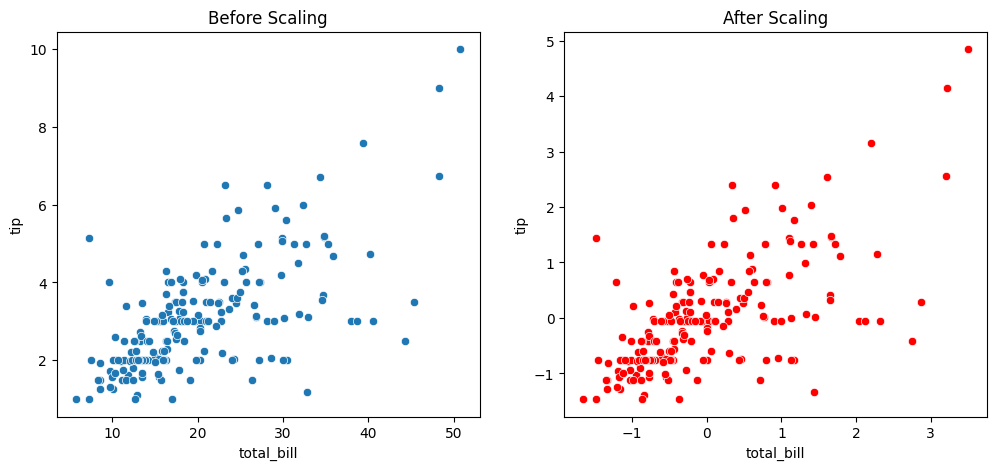

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with 2 side-by-side plots
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot 1: Before Scaling
ax1.set_title('Before Scaling')
sns.scatterplot(x=X_train['total_bill'], y=X_train['tip'], ax=ax1)

# Plot 2: After Scaling
ax2.set_title('After Scaling')
sns.scatterplot(x=X_train_scaled['total_bill'], y=X_train_scaled['tip'], ax=ax2, color='red')

plt.show()

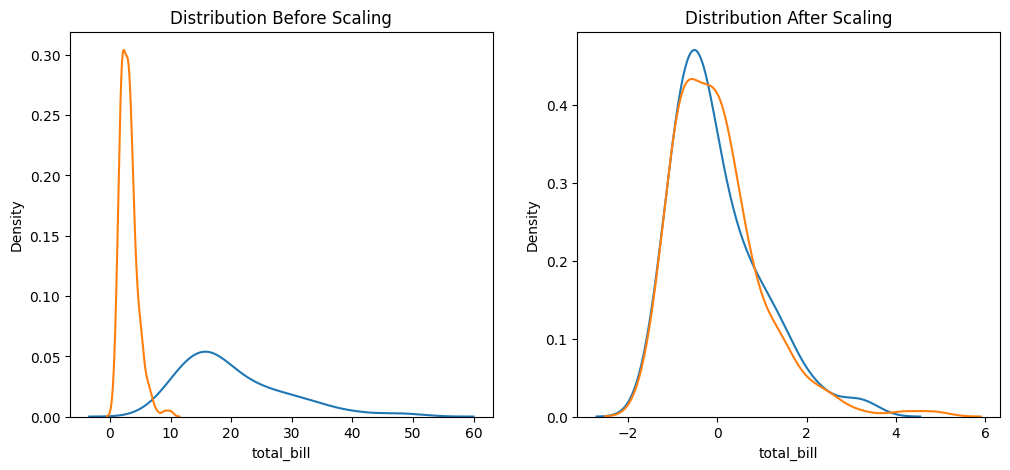

In [9]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before Scaling
ax1.set_title('Distribution Before Scaling')
sns.kdeplot(X_train['total_bill'], ax=ax1)
sns.kdeplot(X_train['tip'], ax=ax1)

# After Scaling
ax2.set_title('Distribution After Scaling')
sns.kdeplot(X_train_scaled['total_bill'], ax=ax2)
sns.kdeplot(X_train_scaled['tip'], ax=ax2)

plt.show()